In [13]:
import matplotlib.pyplot as plt
import json
from pathlib import Path
from datetime import date
import pandas as pd 
import os

### Análise de medalhas

In [14]:
analysis_medals = pd.read_csv("../../bronze/medals_olympics/medals_olympics.csv")

In [39]:
analysis_medals

,Unnamed: 0,year,edition,edition_id,country,country_noc,gold,silver,bronze,total,country_long
0,0,1896.0,1896 Summer Olympics,1.0,Greece,GRE,10,18,19,47,NaN
1,1,1900.0,1900 Summer Olympics,2.0,France,FRA,31,41,40,112,NaN
2,2,1900.0,1900 Summer Olympics,2.0,United States,USA,20,13,15,48,NaN
3,3,1904.0,1904 Summer Olympics,3.0,United States,USA,80,85,83,248,NaN
4,4,1908.0,1908 Summer Olympics,5.0,Great Britain,GBR,56,51,39,146,NaN
...,...,...,...,...,...,...,...,...,...,...,...
1869,1729,2018.0,2018 Winter Olympics,60.0,Norway,NOR,14,14,11,39,NaN
1870,1765,2010.0,2010 Winter Olympics,57.0,United States,USA,9,15,13,37,NaN
1871,1768,2022.0,2022 Winter Olympics,62.0,Norway,NOR,16,8,13,37,NaN
1872,1778,2022.0,2022 Winter Olympics,62.0,ROC,ROC,6,12,14,32,NaN


In [16]:
summer_preprocessed = analysis_medals[analysis_medals["edition"].str.contains("Summer")]
winter_preprocessed = analysis_medals[analysis_medals["edition"].str.contains("Winter")]

summer_medals = (
    summer_preprocessed.groupby("country")[["gold","silver","bronze","total"]]
    .sum()
    .sort_values("total", ascending=False)
)

winter_medals = (
    winter_preprocessed.groupby("country")[["gold","silver","bronze","total"]]
    .sum()
    .sort_values("total", ascending=False)
)


In [17]:
overall_medals = analysis_medals.groupby('country')[["gold","silver","bronze","total"]].sum().sort_values('total',ascending=False)

In [18]:
overall_medals

,gold,silver,bronze,total
country,,,,
United States,1223,1007,881,3111
Soviet Union,473,376,355,1204
Germany,361,381,368,1110
Great Britain,317,350,359,1026
France,288,325,362,975
...,...,...,...,...
Sudan,0,1,0,1
Turkmenistan,0,1,0,1
Tonga,0,1,0,1


In [23]:
def criacao_metadados(path:str, data:list):
    if(os.path.exists(path)):
        pass
    with open(path,"w",encoding="UTF-8") as f:
        json.dump(data,f,ensure_ascii=False,indent=4)

In [34]:
def criar_grafico_50_top(data,string):
    plt.figure(figsize=(10,20))
    plt.barh(data.index, data["total"])
    plt.gca().invert_yaxis()
    plt.xlabel("Total de Medalhas")
    plt.title("Top 50 Países com Mais Medalhas Olímpicas em "+string)

    plt.tight_layout()
    plt.savefig(string+"_plot.png",)

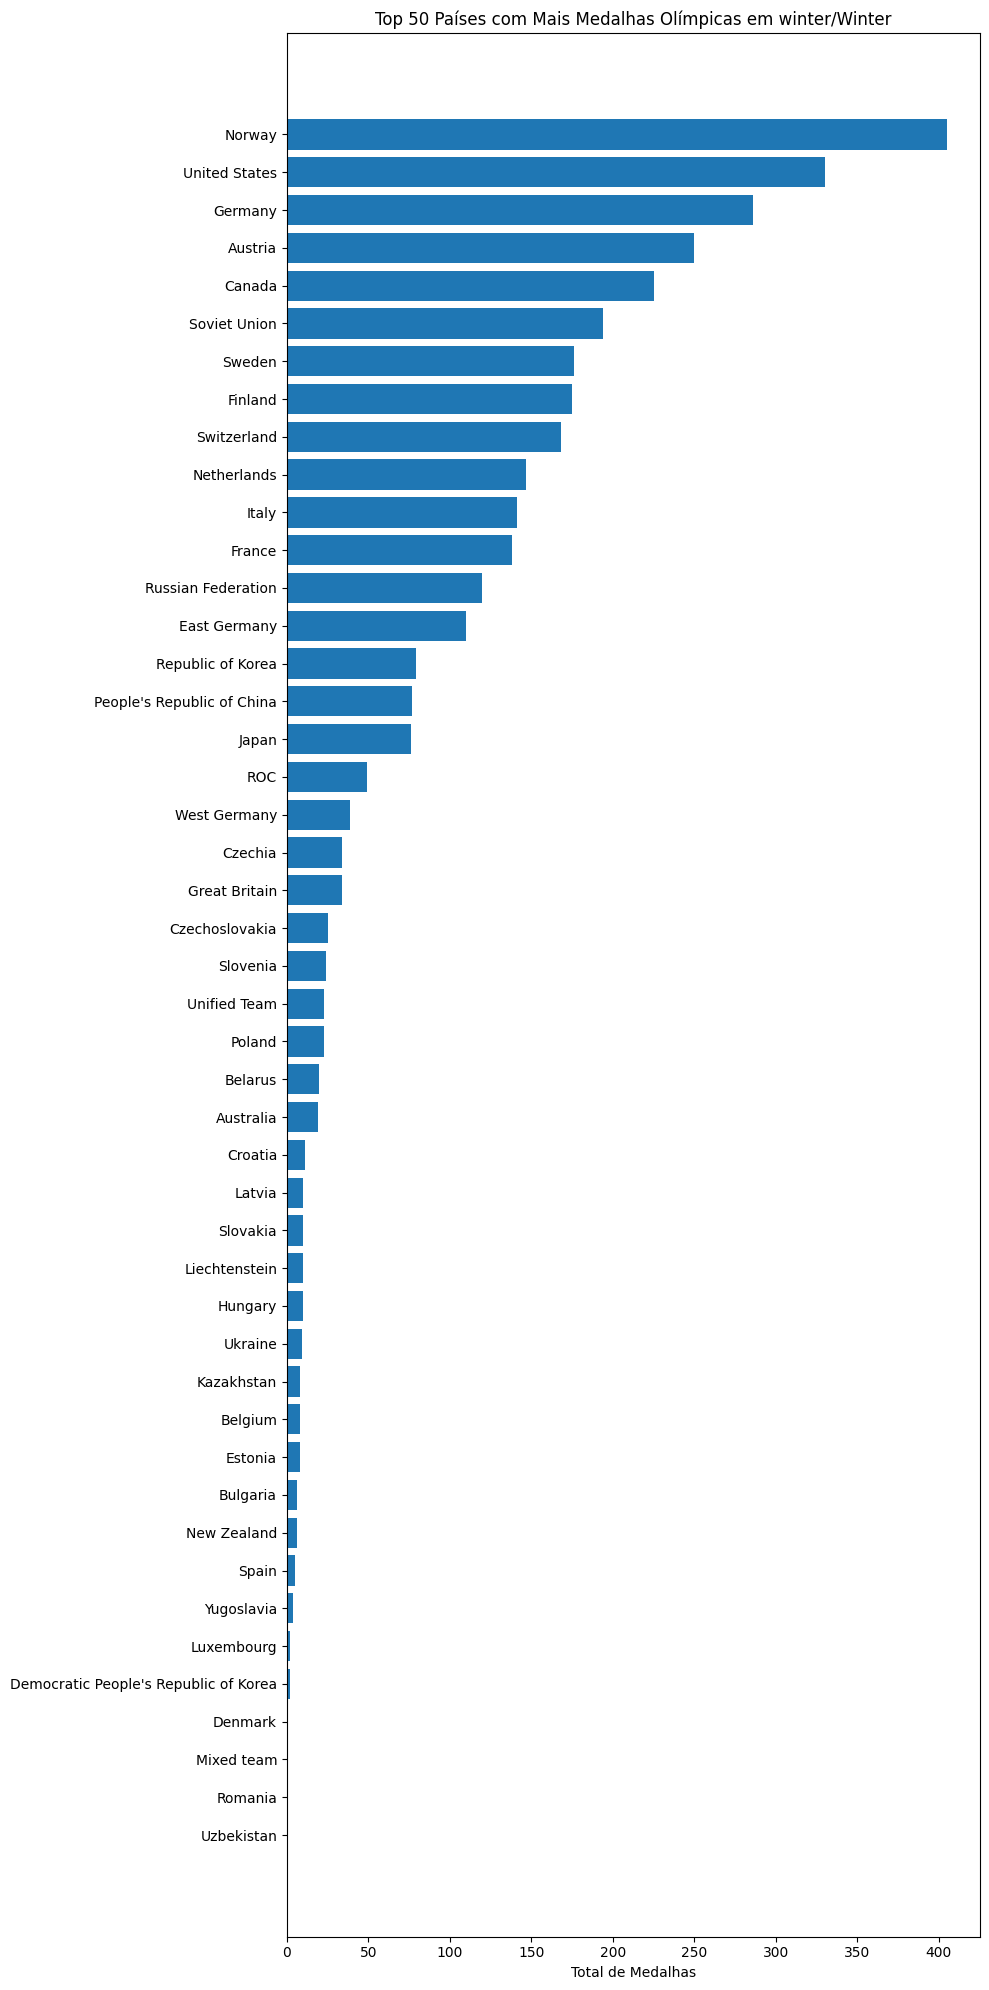

In [36]:
criar_grafico_50_top(winter_medals,"winter/Winter")

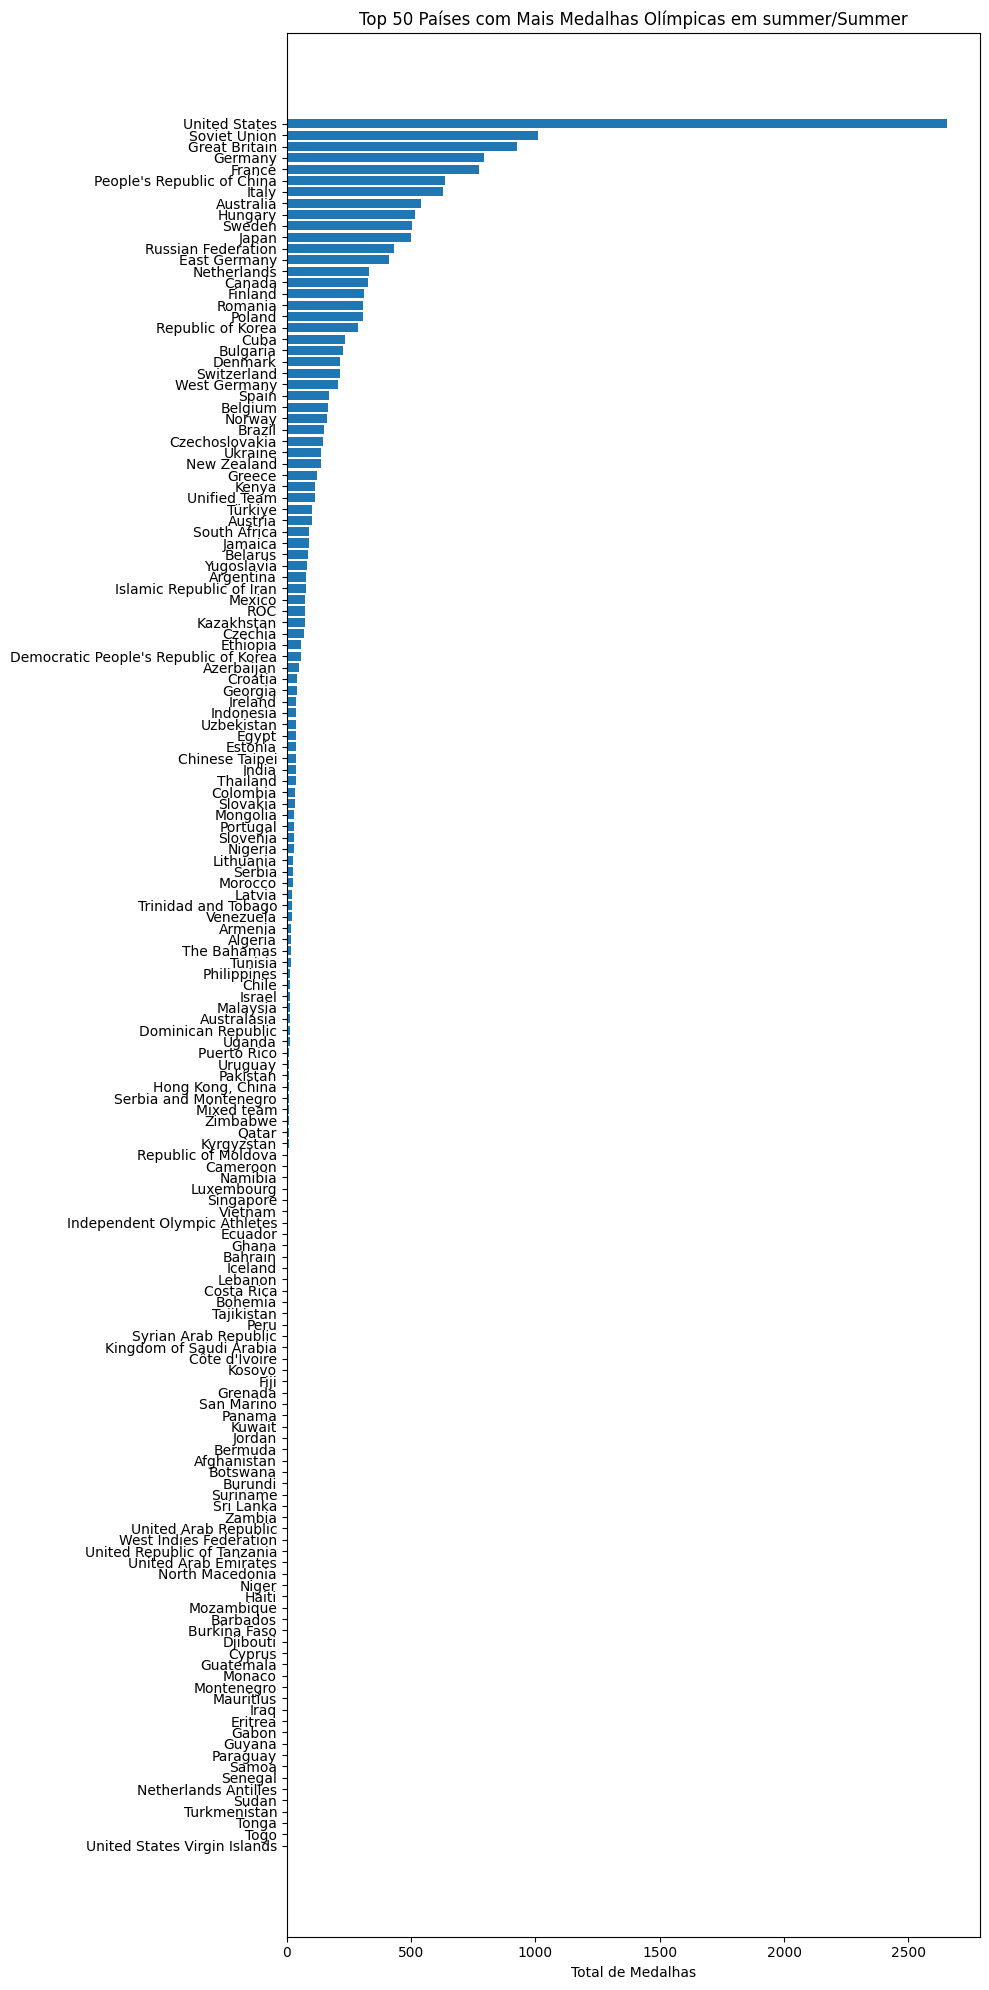

In [38]:
criar_grafico_50_top(summer_medals,"summer/Summer")

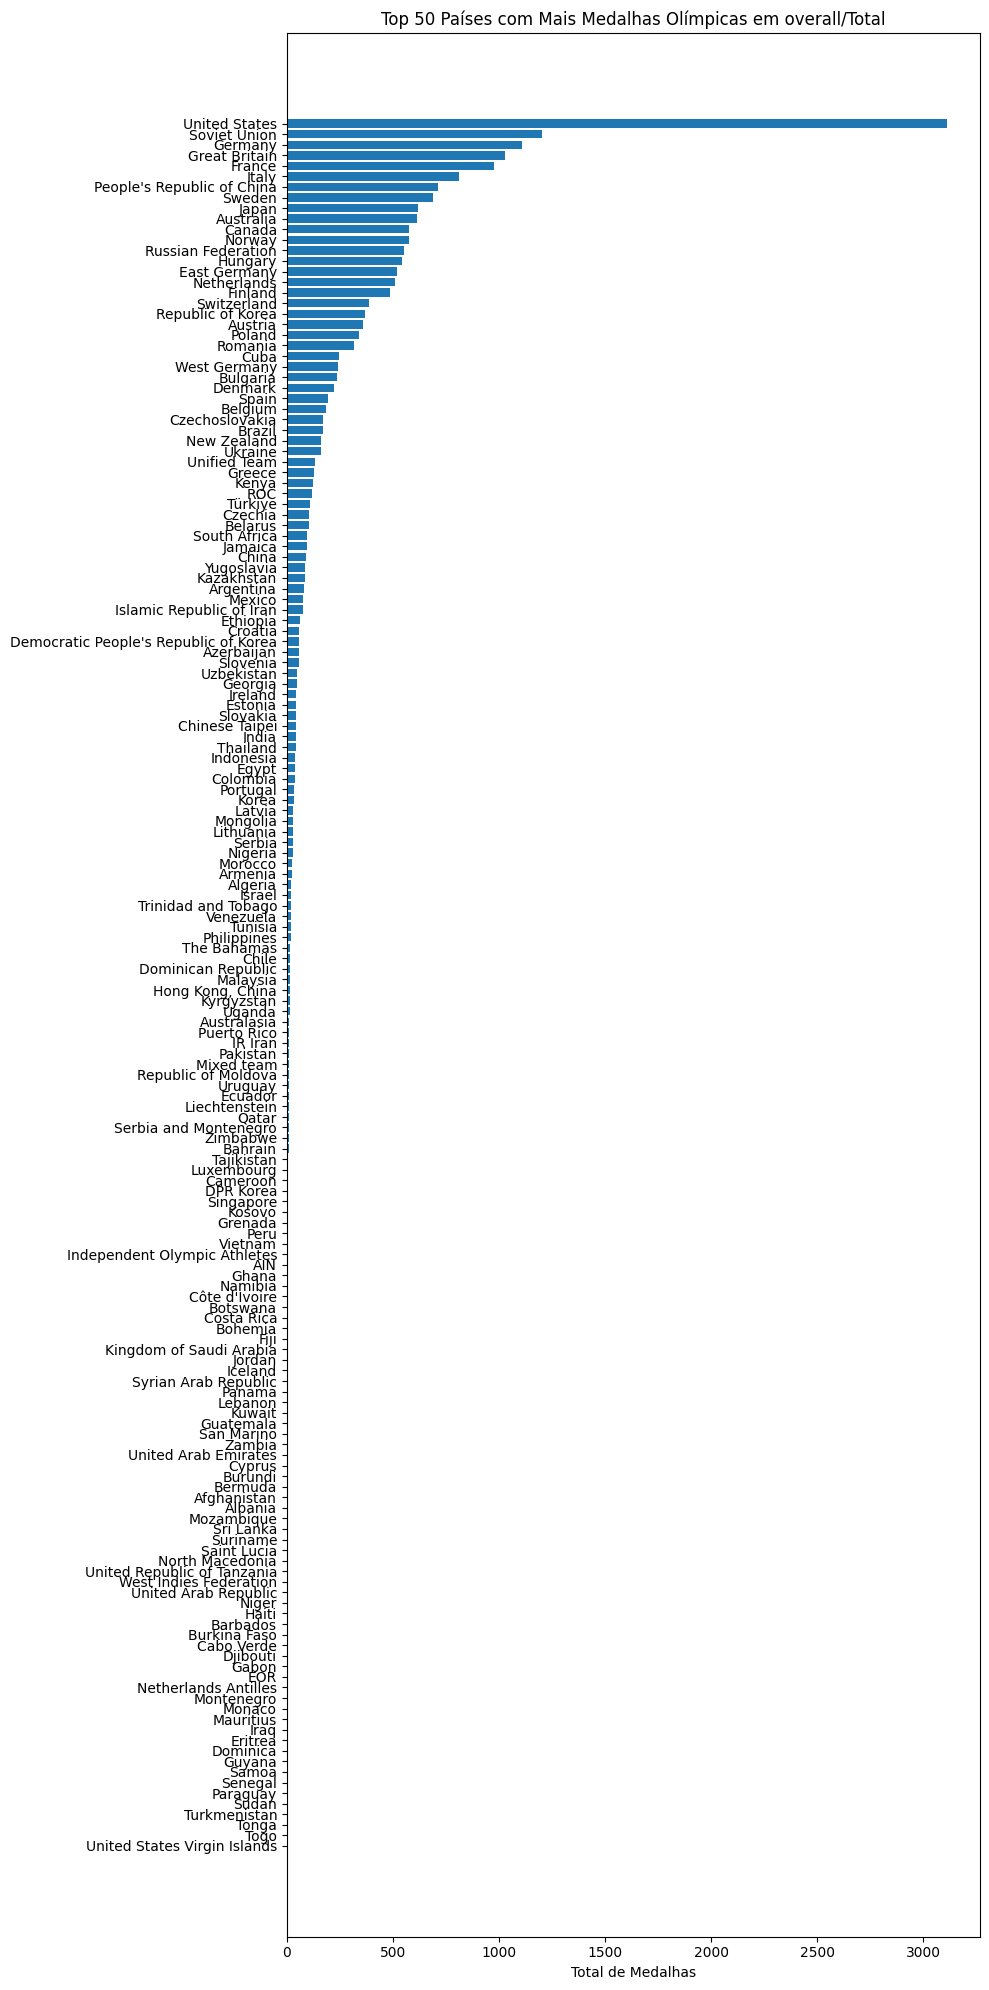

In [37]:
criar_grafico_50_top(overall_medals,"overall/Total")

In [40]:
summer_medals.to_csv("./summer/summer_medals.csv")

In [41]:
winter_medals.to_csv("./winter/winter_medals.csv")

In [42]:
overall_medals.to_csv("./overall/overall_medals.csv")

In [45]:
overall_medals.info()

<class 'pandas.DataFrame'>
Index: 164 entries, United States to United States Virgin Islands
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   gold    164 non-null    int64
 1   silver  164 non-null    int64
 2   bronze  164 non-null    int64
 3   total   164 non-null    int64
dtypes: int64(4)
memory usage: 12.0 KB


In [46]:
summer_medals.info()

<class 'pandas.DataFrame'>
Index: 153 entries, United States to United States Virgin Islands
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   gold    153 non-null    int64
 1   silver  153 non-null    int64
 2   bronze  153 non-null    int64
 3   total   153 non-null    int64
dtypes: int64(4)
memory usage: 11.5 KB


In [48]:
metadata_medals_summer = [
    {
        "arquivo": "summer_medals.csv",
        "descricao": "Dados das medalhas totais das olimpiadas de ver'ao conquistadas pelos países nas respectivas edições dos Jogos Olímpicos",
        "formato": "csv",
        "delimitador": ",",
        "codificacao": "latin1",
        "quantidade_linhas": "153",
        "dataset": "summer_medals.csv",
        "colunas": [
            {
                "nome": "country",
                "tipo_dado": "float64",
                "descricao": "Ano da edição dos Jogos Olímpicos"
            },
            {
                "nome": "gold",
                "tipo_dado": "int64",
                "descricao": "Quantidade de medalhas de ouro totais nas olimpiadas"
            },
            {
                "nome": "silver",
                "tipo_dado": "int64",
                "descricao": "Quantidade de medalhas de prata totais nas olimpiadas"
            },
            {
                "nome": "bronze",
                "tipo_dado": "int64",
                "descricao": "Quantidade de medalhas de bronze totais nas olimpiadas"
            },
            {
                "nome": "total",
                "tipo_dado": "int64",
                "descricao": "Quantidade de medalhas totais nas olimpiadas"
            }
        ]
    }
]

In [49]:
metadata_medals_winter = [
    {
        "arquivo": "winter_medals.csv",
        "descricao": "Dados das medalhas totais das olimpiadas de inverno conquistadas pelos países nas respectivas edições dos Jogos Olímpicos",
        "formato": "csv",
        "delimitador": ",",
        "codificacao": "latin1",
        "quantidade_linhas": "164",
        "dataset": "winter_medals.csv",
        "colunas": [
            {
                "nome": "country",
                "tipo_dado": "float64",
                "descricao": "Ano da edição dos Jogos Olímpicos"
            },
            {
                "nome": "gold",
                "tipo_dado": "int64",
                "descricao": "Quantidade de medalhas de ouro totais nas olimpiadas"
            },
            {
                "nome": "silver",
                "tipo_dado": "int64",
                "descricao": "Quantidade de medalhas de prata totais nas olimpiadas"
            },
            {
                "nome": "bronze",
                "tipo_dado": "int64",
                "descricao": "Quantidade de medalhas de bronze totais nas olimpiadas"
            },
            {
                "nome": "total",
                "tipo_dado": "int64",
                "descricao": "Quantidade de medalhas totais nas olimpiadas"
            }
        ]
    }
]

In [50]:
metadata_medals_overall = [
    {
        "arquivo": "overall_medals.csv",
        "descricao": "Dados das medalhas totais das olimpiadas(Summer + Winter) conquistadas pelos países nas respectivas edições dos Jogos Olímpicos",
        "formato": "csv",
        "delimitador": ",",
        "codificacao": "latin1",
        "quantidade_linhas": "164",
        "dataset": "overall_medals.csv",
        "country,gold,silver,bronze,total"
        "colunas": [
            {
                "nome": "country",
                "tipo_dado": "float64",
                "descricao": "Ano da edição dos Jogos Olímpicos"
            },
            {
                "nome": "gold",
                "tipo_dado": "int64",
                "descricao": "Quantidade de medalhas de ouro totais nas olimpiadas"
            },
            {
                "nome": "silver",
                "tipo_dado": "int64",
                "descricao": "Quantidade de medalhas de prata totais nas olimpiadas"
            },
            {
                "nome": "bronze",
                "tipo_dado": "int64",
                "descricao": "Quantidade de medalhas de bronze totais nas olimpiadas"
            },
            {
                "nome": "total",
                "tipo_dado": "int64",
                "descricao": "Quantidade de medalhas totais nas olimpiadas"
            }
        ]
    }
]

In [52]:
criacao_metadados("./summer/summer_medals.json",metadata_medals_summer)
criacao_metadados("./winter/winter_medals.json",metadata_medals_winter)
criacao_metadados("./overall/overall_medals.json",metadata_medals_overall)